In [1]:
from ISLP import load_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pygam import LinearGAM, terms
from pygam import f as f_gam
from pygam import s as s_gam
from ISLP.pygam import plot as plot_gam
from ISLP.models import bs
from ISLP.pygam import anova as anova_gam
import math
from sklearn.preprocessing import LabelEncoder
import pygam

import statsmodels.api as sm

In [2]:
auto = load_data("Auto")
auto.shape

(392, 8)

In [3]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


### First what we do with our data is exploring them ofc 

In [4]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [5]:
for col in auto.columns:
    print( col , "has < 4 unique vals: ", auto[col].nunique() < 4)
# the last of course because it is binarized Y.


# first .any() search for all values in specified column
# second .any search for null in all columns
print("Has dataset any NaNs? : ",auto.isna().any().any())


mpg has < 4 unique vals:  False
cylinders has < 4 unique vals:  False
displacement has < 4 unique vals:  False
horsepower has < 4 unique vals:  False
weight has < 4 unique vals:  False
acceleration has < 4 unique vals:  False
year has < 4 unique vals:  False
origin has < 4 unique vals:  True
Has dataset any NaNs? :  False


In [6]:
auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
y = auto["mpg"]
X = auto.drop(columns="mpg")
X.head()

,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,
chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,1
buick skylark 320,8,350.0,165,3693,11.5,70,1
plymouth satellite,8,318.0,150,3436,11.0,70,1
amc rebel sst,8,304.0,150,3433,12.0,70,1
ford torino,8,302.0,140,3449,10.5,70,1


<Axes: >

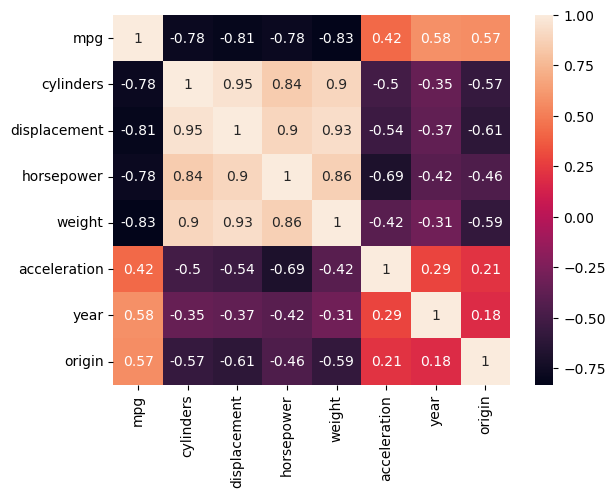

In [8]:
sns.heatmap(auto.corr(), annot=True)

### There are few columns that seems to have strong linear correlation. And it is correct with my intuition.

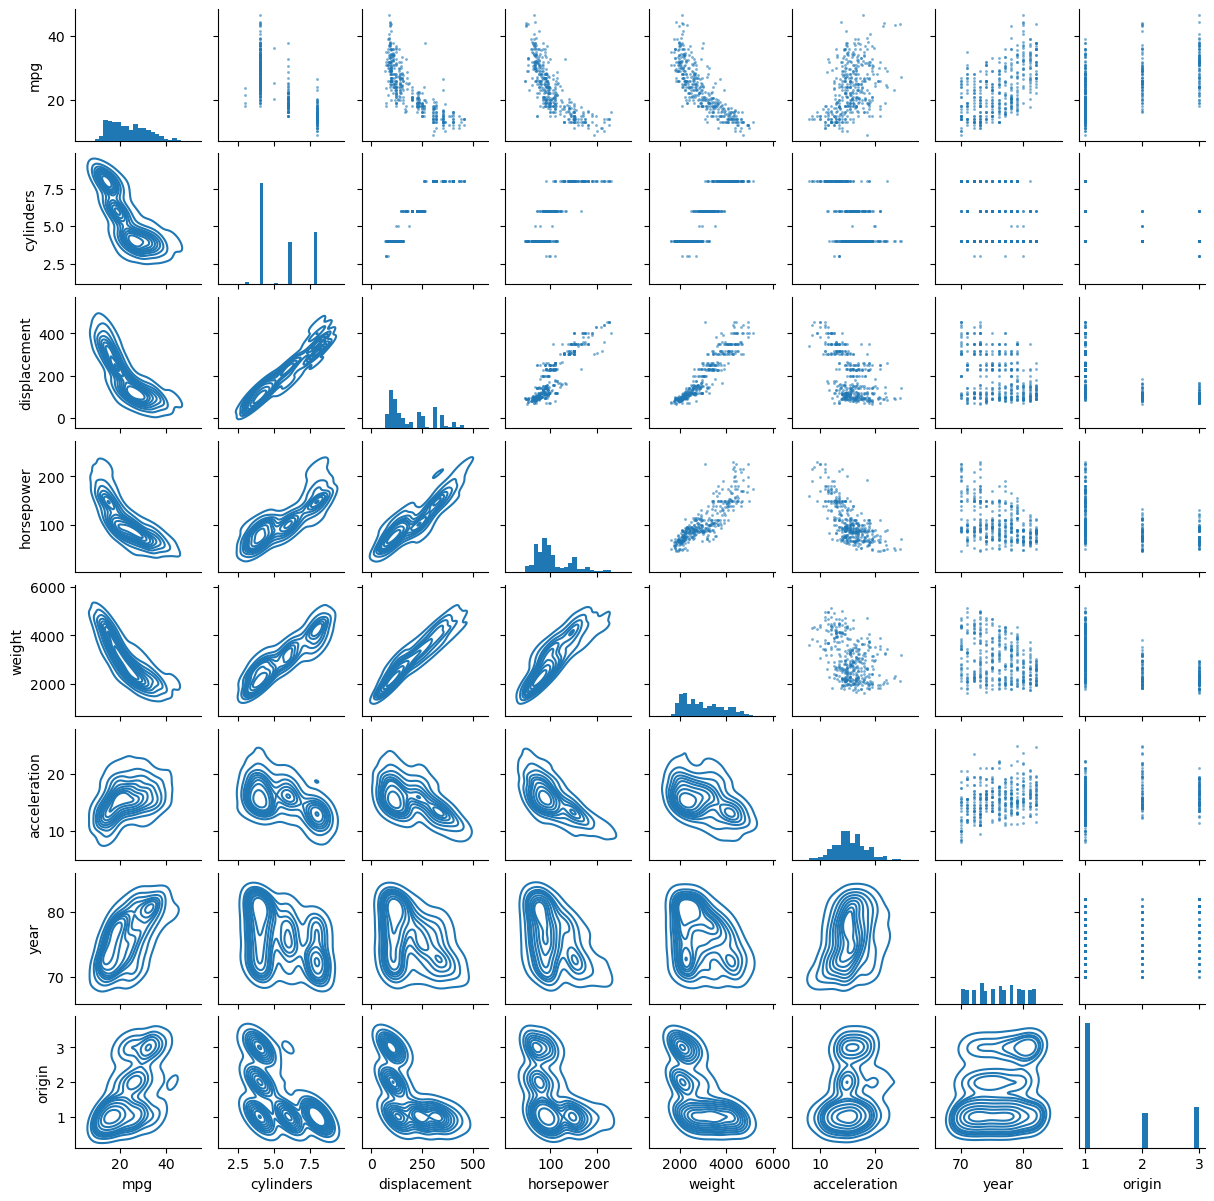

In [9]:
graph = sns.PairGrid(auto)
graph.map_upper(plt.scatter, s=3, linewidths=0.2, alpha=0.6)
graph.map_diag(plt.hist, bins=20)
graph.map_lower(sns.kdeplot)
graph.figure.set_size_inches(12, 12)

##### this shows that few columns tend to have quadratic correlation but it should be verified. 

## Now i want to check if there is any nonlinear relationship.

In [10]:
# this idea is copied from https://mohamed-badry.github.io/islp-solutions/Exercises_ch07.html#applied

def fit_gam(columns: list, df: pd.DataFrame, response: str, s_lam=0.6) -> LinearGAM:
    """ 
    A simple function that fits gam models using factor terms with lam=0 for categorical variables
    and spline terms with default lam=0.6 for numerical variables.
    """
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    gam_terms = [f_gam(i, lam=0) if col in cat_cols else s_gam(i, lam=s_lam) for i, col in enumerate(columns)]
    X_terms = [df[col].cat.codes if col in cat_cols else df[col] for col in columns]
    
    gam = LinearGAM(np.sum(gam_terms))
    Xgam = np.column_stack(X_terms)
    return gam.fit(Xgam, df[response])


def plot_gam_terms(gam, columns: list, df:pd.DataFrame, y_name:str):
    """
    A simple function that plots partial gam plots on one figure
    """
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    n_plots = len(columns)
    n_rows = math.ceil(n_plots/3)
    n_cols = math.ceil(n_plots/n_rows)
    
    _, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        ax = axes[i]
        
        plot_gam(gam, i, ax=ax)
        
        ax.set_xlabel(col)         
        ax.set_ylabel(f'Effect on {y_name}')
        ax.set_title(f'Partial dependence of {col} on {y_name}')
        
        if col in cat_cols:
            ax.set_xticklabels(df[col].cat.categories)
            ax.tick_params(axis='x', labelrotation=23)
            
    plt.tight_layout()

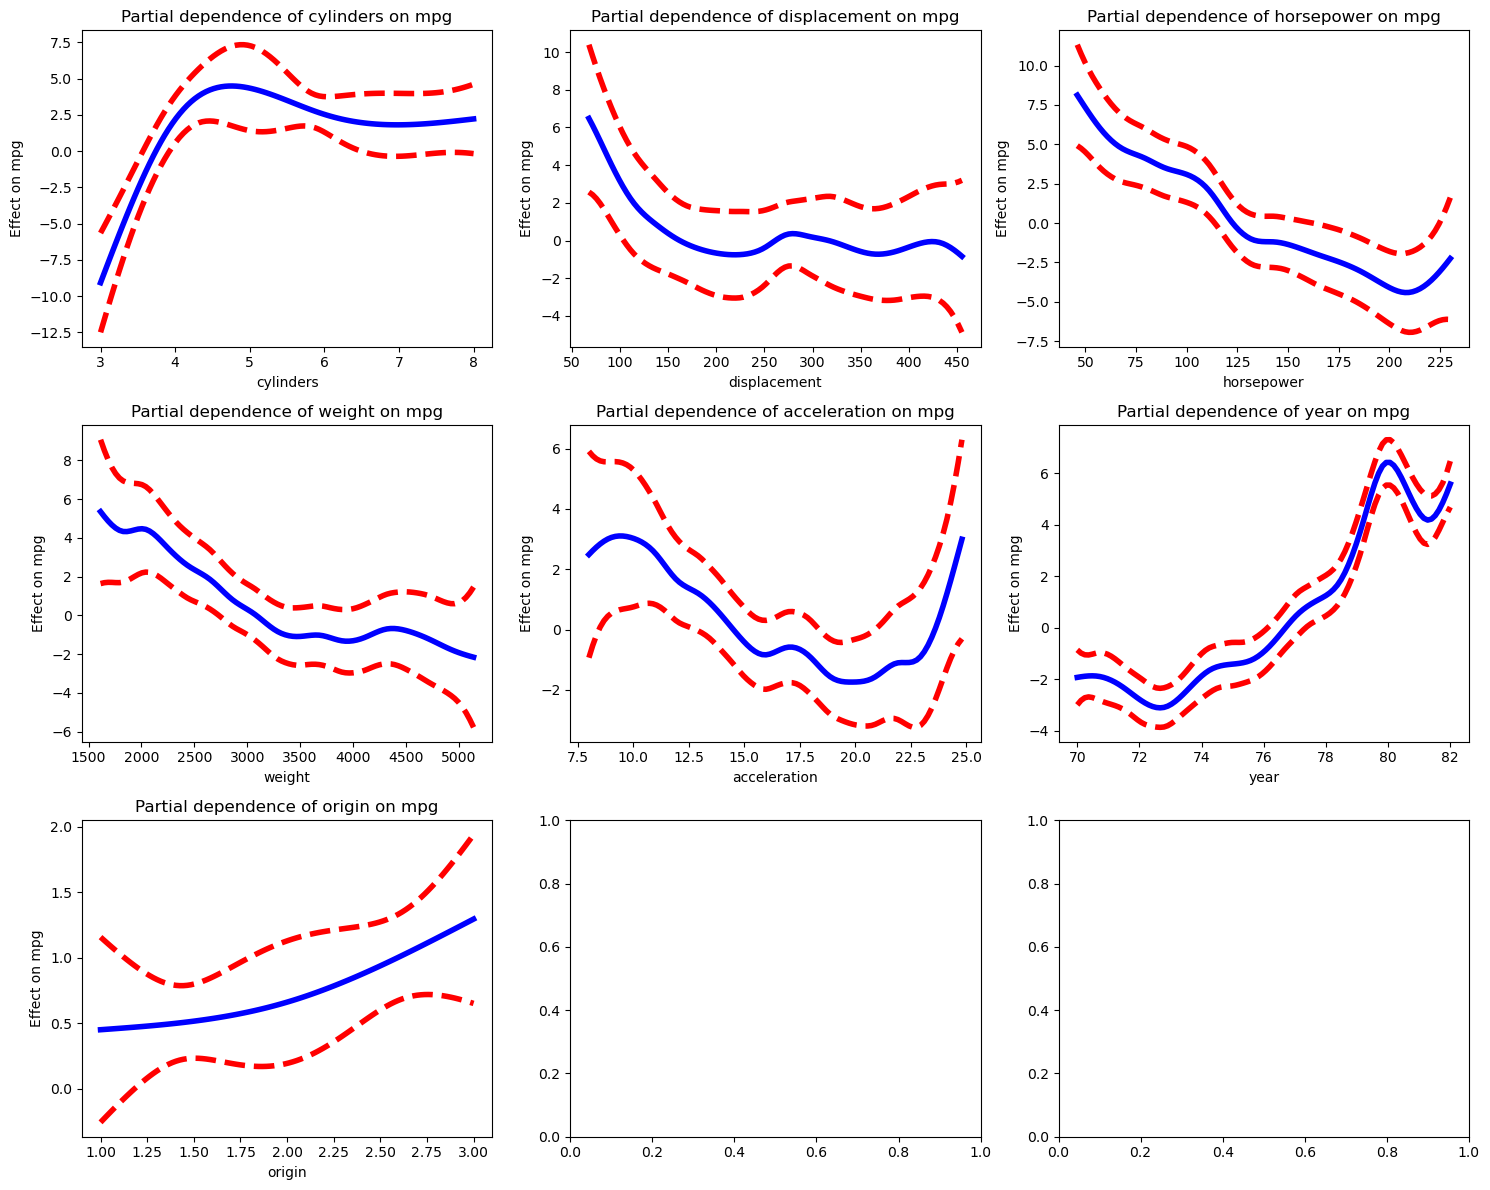

In [11]:
cols = auto.columns.drop('mpg')
gam = fit_gam(cols, auto, response='mpg')
plot_gam_terms(gam, cols, auto, 'mpg')

## Partial dependence shows influence single column on predictor. We can see if in any interval there is growth or decent tendency.

### If partial dependence is not enough, I have come with the idea to make a derivative from GAM to see how fast function changes in some some intervals. It gives me more information, especially to take a better look when function have biggest ups and down.

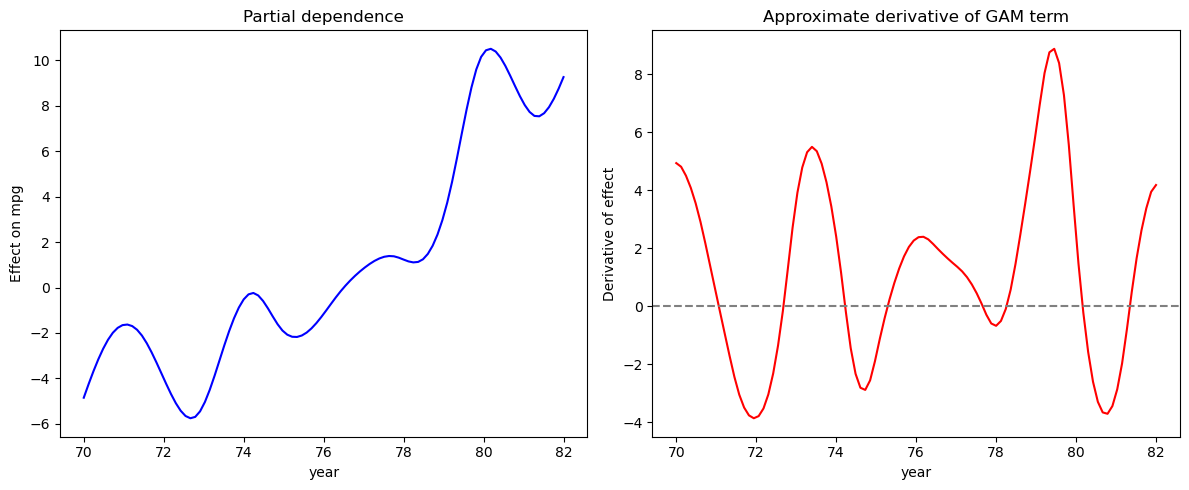

In [12]:
# example on year column
gam = LinearGAM(s_gam(0)).fit(X[['year']].values, y.values)
XX = gam.generate_X_grid(term=0)

pd = gam.partial_dependence(term=0, X=XX)

dx = XX[1,0] - XX[0,0] 
pd_deriv = np.gradient(pd.flatten(), dx)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(XX[:,0], pd, color='blue')
plt.xlabel('year')
plt.ylabel('Effect on mpg')
plt.title('Partial dependence')

plt.subplot(1,2,2)
plt.plot(XX[:,0], pd_deriv, color='red')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('year')
plt.ylabel('Derivative of effect')
plt.title('Approximate derivative of GAM term')

plt.tight_layout()
plt.show()


## To test out another method we can perform Local Regression. This method takes argument "frac" which describe how much percentage of dataset we must include while evaluating a function. The closest points have bigger impact than others. The importance shrinks with the distance.

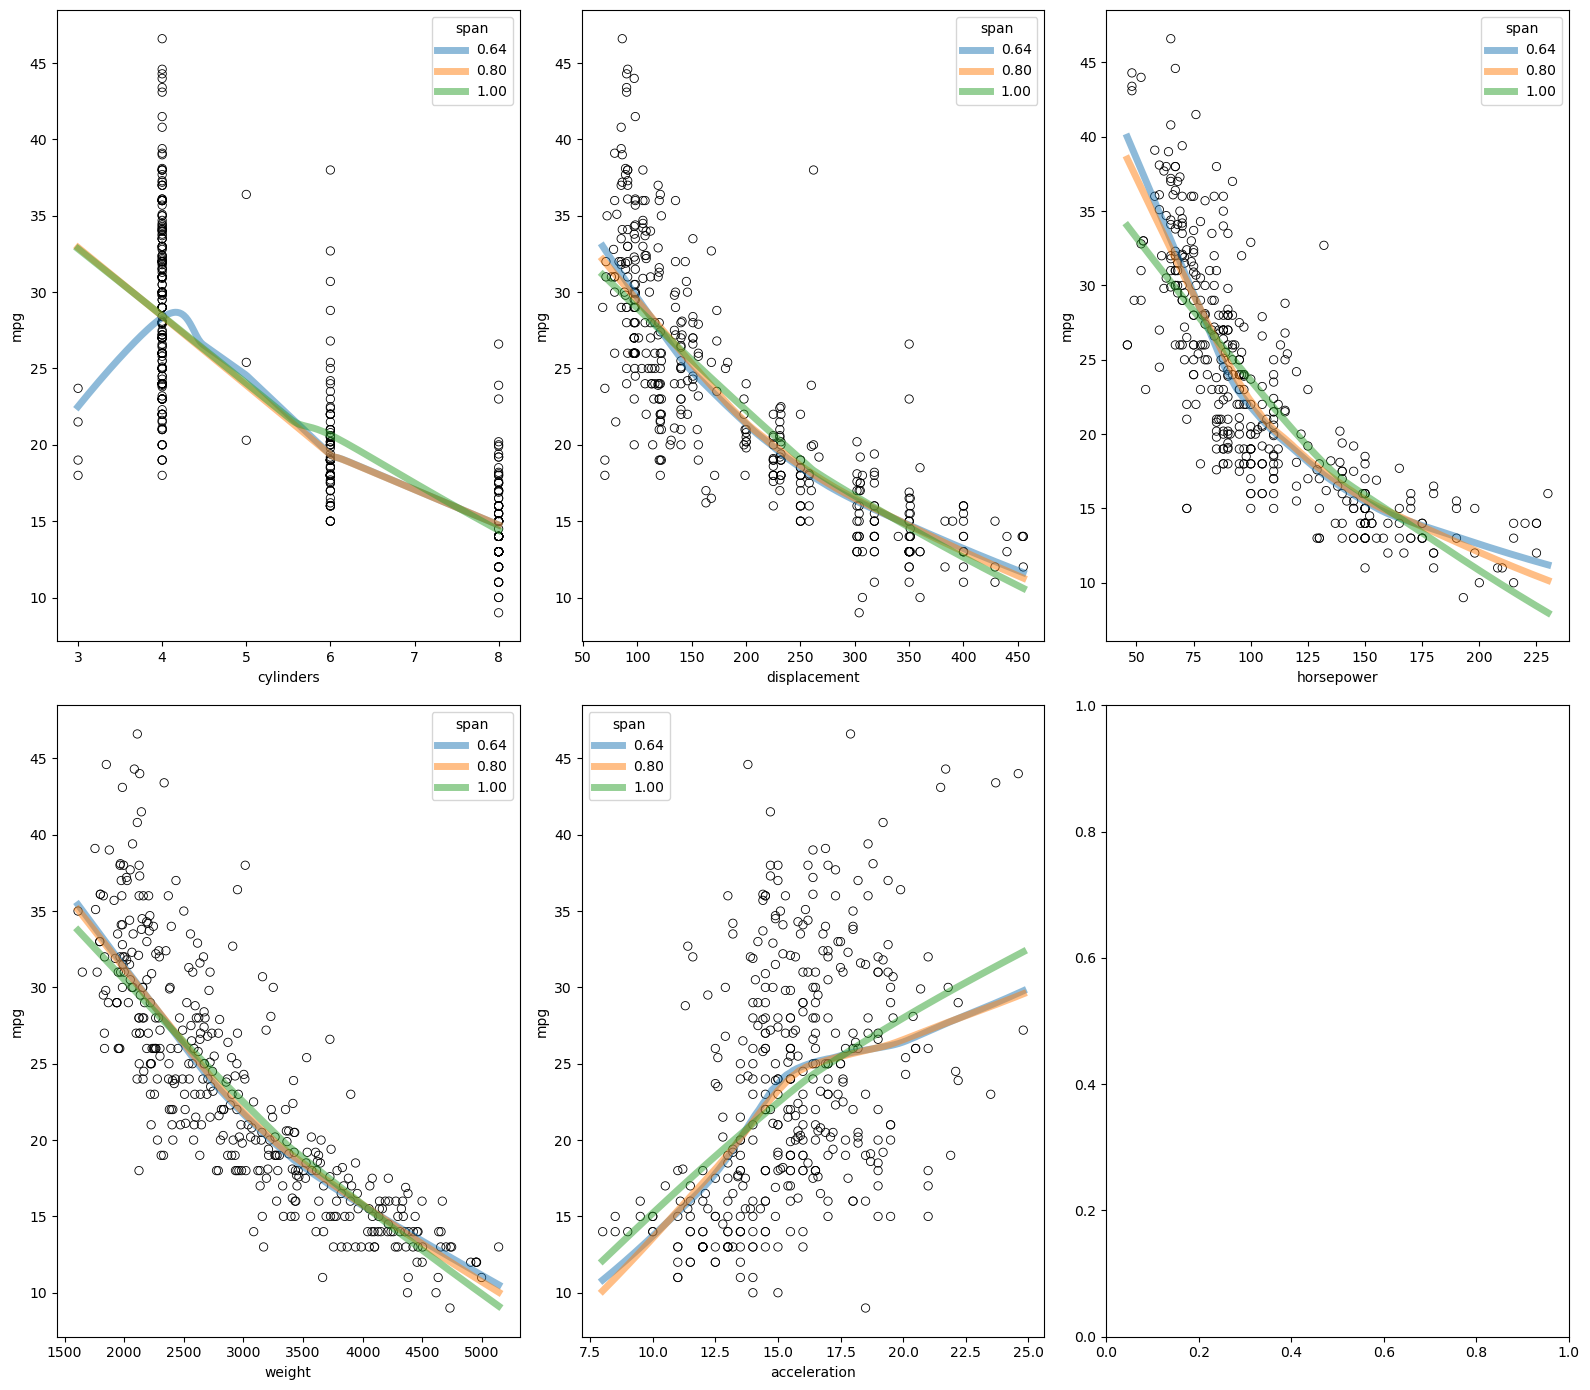

In [21]:
lowess = sm.nonparametric.lowess 
fig, axes = plt.subplots(2, 3, figsize=(16,14))
axes = axes.flatten()
X = X.drop(columns="origin")

for i, col in enumerate(X):
    
    ax = axes[i]
    x_arr = np.linspace(X[col].min(), X[col].max(), 200)
    ax.scatter(X[col], y, marker='o', facecolors='none', edgecolors='black', linewidths=0.6)

    
    
    for span in [0.64, 0.8, 1]:
        fitted = lowess(y,
                        auto[col],
                        frac=span,
                        xvals=x_arr)
        ax.plot(x_arr,
                fitted,
                label=f'{span:.2f}',
                linewidth=5,
                alpha=0.5)

    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('mpg', fontsize=10);
    ax.legend(title='span');

plt.tight_layout()